In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.0
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu
cpu


# 数据预处理

In [ ]:
from pathlib import Path  # 导入 Path 用于处理文件路径

# 定义CIFAR-10数据集的根目录
DATA_DIR = Path("D:/cifar-10")

# 解释语法:
# Path("D:/cifar-10") 使用了 pathlib 库中的 Path 类，将字符串形式的文件路径转换为 Path 对象，方便跨平台和更安全地处理路径拼接等操作。例如，Path("D:/cifar-10")/ "train/train" 会自动使用操作系统正确的分隔符拼接路径，而不用手动加斜杠或反斜杠。

# 定义训练集标签CSV文件路径
train_lables_file = DATA_DIR / "trainLabels.csv"
# 定义测试集模板CSV文件路径（通常用于提交结果的示例）
test_csv_file = DATA_DIR / "sampleSubmission.csv" # 测试集模板csv文件
# 定义训练图片文件夹路径
train_folder = DATA_DIR / "train/train"
# 定义测试图片文件夹路径
test_folder = DATA_DIR / "test/test"

# 定义所有类别的名称，顺序非常重要，通常用于标签到索引的映射
class_names = [
    'airplane',    # 飞机
    'automobile',  # 汽车
    'bird',        # 鸟
    'cat',         # 猫
    'deer',        # 鹿
    'dog',         # 狗
    'frog',        # 青蛙
    'horse',       # 马
    'ship',        # 船
    'truck',       # 卡车
]

import pandas as pd  # 导入pandas用于csv读取和数据处理

def load_image_paths_and_labels(labels_csv_path, images_folder):
    """
    读取标签CSV文件，为每张图片生成完整路径，并返回[(img_path, label), ...]的列表

    参数:
        labels_csv_path: CSV文件路径，文件中应包含图片id和对应标签
        images_folder: 图片所在文件夹的路径

    返回:
        items: 列表，包含(img_path, label)元组
    """
    # 读取标签csv文件
    df = pd.read_csv(labels_csv_path)
    items = []  # 用于存储(img_path, label)元组的列表

    # INSERT_YOUR_CODE
    # iterrows 是pandas中DataFrame的一个迭代器方法，用于逐行遍历数据。
    # 它会返回每一行的索引（index）和行数据（Series对象），可以用 for idx, row in df.iterrows(): 来循环获取每一行的数据。
    # 常用于依次处理或访问DataFrame的每一行内容（如本函数下面用于访问id, label）。
    
    for idx, row in df.iterrows():
        img_name = row['id']  # 从csv读取图片名（不包含扩展名）
        label = row['label']  # 从csv读取类别标签
        # 尝试拼接png格式的图片完整路径
        img_path = images_folder / f"{img_name}.png"
        # 如果png不存在，则尝试jpg格式（确保适配两种格式的图片）
        if not img_path.exists():
            img_path = images_folder / f"{img_name}.jpg"
        # 将图片路径和标签作为元组添加到列表中
        items.append( (str(img_path), label) )
    return items

# 示例：加载训练集和测试集的图片路径及其标签
train_items = load_image_paths_and_labels(train_lables_file, train_folder)
test_items = load_image_paths_and_labels(test_csv_file, test_folder)

import pprint  # 导入pprint便于更美观地打印数据结构
# 打印训练集前5条样例，检查数据格式是否正确
pprint.pprint(train_items[:5])



[('D:\\cifar-10\\train\\train\\1.png', 'frog'),
 ('D:\\cifar-10\\train\\train\\2.png', 'truck'),
 ('D:\\cifar-10\\train\\train\\3.png', 'truck'),
 ('D:\\cifar-10\\train\\train\\4.png', 'deer'),
 ('D:\\cifar-10\\train\\train\\5.png', 'automobile')]


In [12]:
pprint.pprint(test_items[:5])

[('D:\\cifar-10\\test\\test\\1.png', 'cat'),
 ('D:\\cifar-10\\test\\test\\2.png', 'cat'),
 ('D:\\cifar-10\\test\\test\\3.png', 'cat'),
 ('D:\\cifar-10\\test\\test\\4.png', 'cat'),
 ('D:\\cifar-10\\test\\test\\5.png', 'cat')]


In [2]:
import pandas as pd  # 导入pandas用于数据结构操作

# 给出train和test的长度
print(f"train_items数量: {len(train_items)}")
print(f"test_items数量: {len(test_items)}")

# 将train_items按顺序切分为训练集和验证集
# 训练集：前45000条样本用于模型训练
train_items_ = train_items[:45000]
# 验证集：剩余后5000条样本用于模型验证
valid_items_ = train_items[45000:]

# 将训练集列表转换为DataFrame以便后续统一处理
# 每一行为一张图片：包含图片完整路径(img_path)和对应的标签(label)
train_df = pd.DataFrame(train_items_, columns=["img_path", "label"])

# 同理，将验证集样本转为DataFrame
valid_df = pd.DataFrame(valid_items_, columns=["img_path", "label"])

# 测试集全部样本转为DataFrame
test_df = pd.DataFrame(test_items, columns=["img_path", "label"])


NameError: name 'train_items' is not defined

In [ ]:
from PIL import Image  # 引入PIL用于图像处理
from torch.utils.data import Dataset, DataLoader  # 引入PyTorch的数据集与数据加载器
from torchvision import transforms  # 用于进行图像增强和预处理

class Cifar10Dataset(Dataset):
    # 定义不同模式（训练、验证、测试）对应的DataFrame映射
    df_map = {
        "train": train_df,   # 训练集
        "eval": valid_df,    # 验证集
        "test": test_df      # 测试集
    }
    # 类别到索引的映射字典，例如{'cat': 0, 'dog': 1, ...}
    label_to_idx = {label: idx for idx, label in enumerate(class_names)}
    # 索引到类别的映射（反向），便于做可视化或结果解析
    idx_to_label = {idx: label for idx, label in enumerate(class_names)}

    def __init__(self, mode, transform=None):
        """
        初始化方法
        :param mode: 模式，str类型，"train"、"eval"、"test" 之一
        :param transform: 图像预处理/增强的transform
        """
        # 获取对应模式的DataFrame数据
        # 这是通过字典的get方法，根据传入的mode参数从df_map中取出对应的DataFrame（如"train"、"eval"、"test"），如果mode不存在则返回None
        self.df = self.df_map.get(mode, None)
        if self.df is None:
            raise ValueError("mode should be one of train, val, test, but got {}".format(mode))
        # 保存transform，用于后续图像增强
        self.transform = transform
        
    def __getitem__(self, index):
        """
        获取指定index的样本（图片、标签）
        :param index: 索引，可以自动被DataLoader批量调用
        :return: (图像Tensor, 标签索引)
        """
        # 读取图片路径和字符串标签
        img_path, label = self.df.iloc[index]
        # 打开图片并转为RGB格式（防止灰度图或带透明通道等问题）
        img = Image.open(img_path).convert('RGB')
        # 对图片进行transform操作（如数据增强、归一化等）
        img = self.transform(img)
        # label转为索引（int型，用于分类模型训练）
        label = self.label_to_idx[label]
        return img, label
    
    def __len__(self):
        """
        返回数据集样本总数
        """
        return self.df.shape[0]  # DataFrame的行数就是样本数

# 数据集图片缩放大小
IMAGE_SIZE = 32
# 图像归一化均值与标准差（CIFAR10官方推荐参数，3个通道）
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]

# 定义训练集的数据增强/预处理
transforms_train = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),        # 重设尺寸
    transforms.RandomRotation(40),                      # 随机旋转，增强鲁棒性
    transforms.RandomHorizontalFlip(),                  # 随机水平翻转
    transforms.ToTensor(),                              # 转为Tensor，[H, W, C] -> [C, H, W]并归一化至[0,1]
    transforms.Normalize(mean, std)                     # 标准化，每个通道减均值除以标准差
])

# 定义验证集和测试集的预处理（不做增强，仅缩放、归一化）
transforms_eval = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),        # 重设尺寸
    transforms.ToTensor(),                              # 转为Tensor
    transforms.Normalize(mean, std)                     # 标准化
])

# 构建训练集和验证集Dataset对象
train_ds = Cifar10Dataset("train", transforms_train)  # 训练集，含数据增强
eval_ds = Cifar10Dataset("eval", transforms_eval)     # 验证集，不含数据增强（只做归一化等）

In [15]:

# 对train_ds计算均值和标准差
# from torch.utils.data import DataLoader
# import torch
# 
# loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=2)
# 
# mean = torch.zeros(3)
# std = torch.zeros(3)
# n_pixels = 0
# 
# for images, _ in loader:  # images: [B, 3, H, W]
#     batch_pixels = images.shape[0] * images.shape[2] * images.shape[3]
#     mean += images.sum([0, 2, 3])
#     std += (images ** 2).sum([0, 2, 3])
#     n_pixels += batch_pixels
# 
# mean /= n_pixels
# std = torch.sqrt(std / n_pixels - mean ** 2)
# 
# print("train_ds按通道均值:", mean)
# print("train_ds按通道标准差:", std)



In [16]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
)

test_loader = DataLoader(
    eval_ds,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
for batch_images, batch_labels in train_loader:
    print(f"批次图像张量形状: {batch_images.shape}")
    print(f"批次标签张量形状: {batch_labels.shape}")
    print(batch_labels)
    break

训练集DataLoader批次数: 1407
测试集DataLoader批次数: 157
每个批次大小: 32
批次图像张量形状: torch.Size([32, 3, 32, 32])
批次标签张量形状: torch.Size([32])
tensor([4, 1, 7, 2, 5, 9, 1, 6, 8, 8, 8, 0, 6, 3, 6, 0, 9, 5, 9, 7, 4, 8, 9, 5,
        2, 8, 1, 1, 2, 1, 0, 8])


# 搭建模型

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        """
        构建一个多层卷积神经网络用于CIFAR10分类
        
        参数：
        num_classes (int): 输出类别数量
        """
        super().__init__()
        self.model = nn.Sequential(
            # 第一组卷积层：输入通道3（RGB），输出通道128，卷积核3x3，padding=same保持特征图尺寸
            nn.Conv2d(in_channels=3, out_channels=128, kernel_size=3, padding="same"),
            nn.ReLU(),  # 激活函数，增加非线性特征
            nn.BatchNorm2d(128), # 批标准化，对128通道每个做归一化，加快收敛
            
            # 第二组卷积层：输入128通道，输出128通道
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same"), # 输出尺寸: (128, 32, 32)
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2), # 最大池化，尺寸减半，输出: (128, 16, 16)
            
            # 第三组卷积层：输入128通道，输出256通道
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            
            # 第四组卷积层：输入256通道，输出256通道
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding="same"), # 输出尺寸: (256, 16, 16)
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2), # 输出: (256, 8, 8)
            
            # 第五组卷积层：输入256通道，输出512通道
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            
            # 第六组卷积层：输入512通道，输出512通道
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding="same"), # 输出尺寸: (512, 8, 8)
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2), # 输出: (512, 4, 4)
            
            # 展平操作，将高维特征拉平成一维向量（512*4*4=8192）
            nn.Flatten(),
            
            # 全连接层：输入8192个特征，输出512个特征
            nn.Linear(8192, 512),
            nn.ReLU(),
            
            # 输出层：将512维特征转换为num_classes类别得分
            nn.Linear(512, num_classes),
        )  # nn.Sequential容器自动串联上面的各层
        
    def forward(self, x):
        """
        前向传播函数

        参数：
        x (Tensor): 输入的图像张量，形状为 (batch_size, 3, 32, 32)
        
        返回：
        logits (Tensor): 模型输出类别分数，未经过softmax
        """
        return self.model(x)
        
    
# 初始化模型，类别数由class_names的长度确定，如CIFAR10为10
model = CNN(num_classes=len(class_names))


In [35]:
128*16*16*256

8388608

In [20]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 3, 32, 32) 
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [21]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
model.0.weight: 3456
model.0.bias: 128
model.2.weight: 128
model.2.bias: 128
model.3.weight: 147456
model.3.bias: 128
model.5.weight: 128
model.5.bias: 128
model.7.weight: 294912
model.7.bias: 256
model.9.weight: 256
model.9.bias: 256
model.10.weight: 589824
model.10.bias: 256
model.12.weight: 256
model.12.bias: 256
model.14.weight: 1179648
model.14.bias: 512
model.16.weight: 512
model.16.bias: 512
model.17.weight: 2359296
model.17.bias: 512
model.19.weight: 512
model.19.bias: 512
model.22.weight: 4194304
model.22.bias: 512
model.24.weight: 5120
model.24.bias: 10
模型总参数量: 8779914


In [16]:
32*3*3*64

18432

# 训练

In [22]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [23]:
import wangdao_train
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100
)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer.train(num_epochs)


[Step 100] Val Loss: 2.0814 Val Acc: 0.2794
[Step 200] Val Loss: 1.7145 Val Acc: 0.3688
[Step 300] Val Loss: 1.6563 Val Acc: 0.3850


KeyboardInterrupt: 

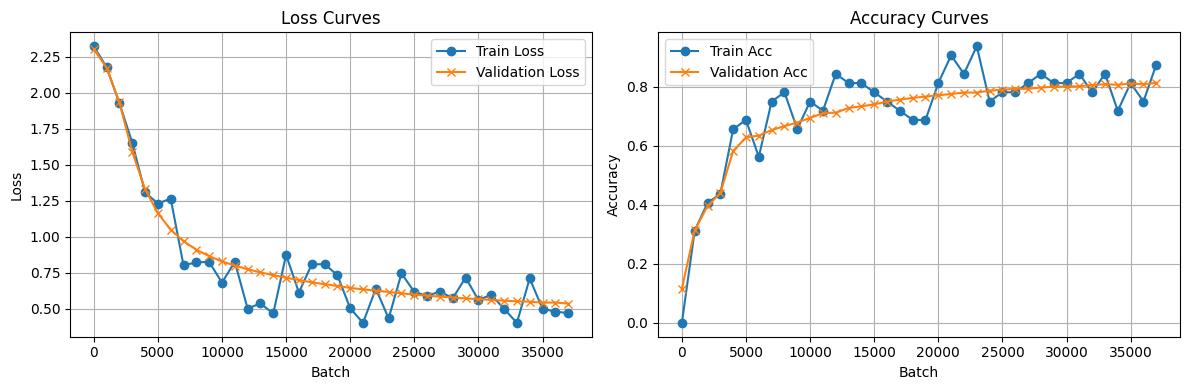

In [ ]:
trainer.plot_curves()


In [ ]:
# 构建test_ds并进行推理，将预测结果写入csv文件

# 假设Cifar10Dataset类以及transforms_eval已经正确定义
# 创建测试集数据集对象（test_ds），此数据集将应用评估用的数据增强/预处理方法
test_ds = Cifar10Dataset("test", transforms_eval)

# 构建测试集 DataLoader，batch_size设为128，不进行洗牌（保持样本顺序）
test_loader_final = torch.utils.data.DataLoader(
    test_ds, 
    batch_size=128, 
    shuffle=False
)

all_preds = []  # 存储所有测试集样本的预测类别

# 设置模型为评估模式，关闭Dropout/BN等训练相关层
model.eval()

# 进入no_grad上下文，禁用梯度计算，加快推理速度&节省内存
# 进入no_grad上下文，禁用梯度计算，加快推理速度&节省内存
# all_preds: list[int]，保存测试集所有样本的预测类别（长度为测试集样本总数）
# data: tuple(Tensor, )，DataLoader每次输出的batch，例如(data[0], )，其中data[0]为图片batch
# data[0]: torch.Tensor，shape=[batch_size, 3, 32, 32]，类型为float32
# images: torch.Tensor，shape=[batch_size, 3, 32, 32]，类型为float32，已被转到device（cuda/cpu）
# outputs: torch.Tensor，shape=[batch_size, num_classes]，类型为float32，记录每个样本各类别的logits
# predicted: torch.Tensor，shape=[batch_size]，类型为long，记录每个样本的预测类别下标


# dataset是一个自定义的数据集对象（如Cifar10Dataset），它存放着所有原始数据（如图片和对应标签），其元素通常为单个样本的数据（如一张图片及其标签）。类型是自定义的Dataset类，getitem返回一般为元组(images, label)；测试集则可能只返回images。
# images: torch.Tensor，形状：[3, 32, 32]，类型：float32
# label: int

# dataloader是一个批量加载数据的迭代器（如torch.utils.data.DataLoader），它每次迭代返回一个batch的数据，即从dataset取出batch_size个元素并组合成一个batch。类型是torch.utils.data.DataLoader，输出通常为一个元组(images, labels)。
# images: torch.Tensor，形状：[batch_size, 3, 32, 32]，类型：float32
# labels: torch.Tensor（或None，若是测试集无label），形状：[batch_size]，类型：long/int64


with torch.no_grad():
    for data in test_loader_final:
        # 从DataLoader中取出一批数据，此处data[0]为图像张量
        # data 是 DataLoader 每次输出的一个 batch，通常是 (inputs, targets) 或其他结构
        # 在上面的 Cifar10Dataset 中，如果只返回图片（测试集没有标签），data[0] 就是当前 batch 的所有图片张量
        # data[0].shape 通常为 [batch_size, 通道数, 高, 宽]，比如 [128, 3, 32, 32]
        # 如果你 print(type(data), len(data))，也可以进一步确认结构
        images = data[0]
        # 将图片数据转移到训练使用的设备上（如cuda/CPU）
        images = images.to(device)
        # 前向推理，获得输出张量（logits）
        outputs = model(images)
        # 取每一行（每张图片）输出中概率最大的位置作为预测类别
        _, predicted = outputs.max(1)
        # 将预测结果转为CPU numpy格式，并转为list添加到all_preds
        all_preds.extend(predicted.cpu().numpy().tolist())

import pandas as pd  # 引入pandas用于保存csv文件

# 创建一个DataFrame，包含测试集各样本的id以及对应预测label
df = pd.DataFrame({
    "id": list(1, range(len(all_preds)) + 1),  # id列默认为1~N（与测试集顺序对应）
    "label": all_preds                  # label列对应预测结果
})

# 将DataFrame写入csv文件，不输出行索引
df.to_csv("cifar10_test_pred.csv", index=False)
